In [1]:
import os
lettersPath=r"C:\Users\pavle\OneDrive\Desktop\DtSci_Vezbanje\Ocr_Dataset_Analysis\Letters"
imgData=[]
letterClasses=[]
for label in os.listdir(lettersPath):
    letterClasses.append([label])
    labelPath=os.path.join(lettersPath,label)
    if os.path.isdir(labelPath):
        for imgName in os.listdir(labelPath):
            imagePath=os.path.join(labelPath,imgName)
            imgData.append([imagePath,label])



<Axes: xlabel='Label'>

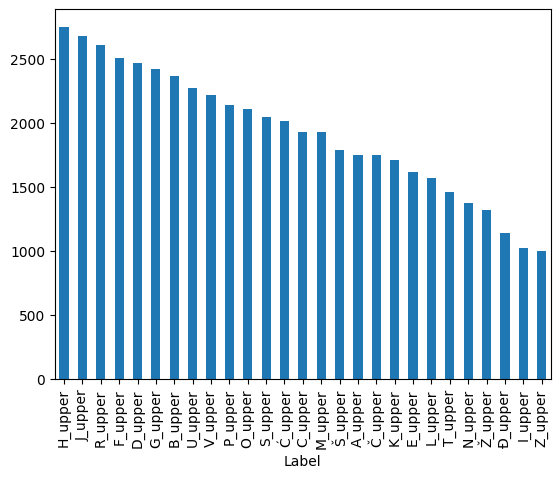

In [2]:
import pandas as pd 

df=pd.DataFrame(imgData,
                columns=["File Destination","Label"])
df.head(10)
df['Label'].value_counts().plot(kind="bar")


In [ ]:

labelDF=df['Label'].value_counts()
print(labelDF.describe())

count      27.000000
mean     1925.555556
std       504.403862
min      1001.000000
25%      1594.000000
50%      1933.000000
75%      2320.000000
max      2751.000000
Name: count, dtype: float64


In [4]:
print(labelDF)

Label
H_upper    2751
J_upper    2679
R_upper    2610
F_upper    2511
D_upper    2467
G_upper    2419
B_upper    2366
U_upper    2274
V_upper    2219
P_upper    2141
O_upper    2110
S_upper    2048
Ć_upper    2019
C_upper    1933
M_upper    1928
Š_upper    1792
A_upper    1754
Č_upper    1747
K_upper    1708
E_upper    1614
L_upper    1574
T_upper    1464
N_upper    1378
Ž_upper    1319
Đ_upper    1139
I_upper    1025
Z_upper    1001
Name: count, dtype: int64


In [5]:

najveci_element=labelDF.idxmax()
broj_najveceg_elementa=labelDF.max()
print(f"Najveci element je: {najveci_element} i on ima {broj_najveceg_elementa} slova!")
najmanji_element=labelDF.idxmin()
broj_najmanjeg_elementa=labelDF.min()
print(f"Najmanji element je: {najmanji_element} i on ima {broj_najmanjeg_elementa} slova!")

Najveci element je: H_upper i on ima 2751 slova!
Najmanji element je: Z_upper i on ima 1001 slova!


Label
L_upper     9.559760
Š_upper     9.598566
Ć_upper    10.007163
Č_upper    10.232840
J_upper    10.360855
F_upper    10.891916
I_upper    11.694874
T_upper    12.229306
P_upper    12.706722
H_upper    12.824551
D_upper    13.714604
R_upper    14.059099
V_upper    14.136203
S_upper    14.472126
G_upper    14.515502
Ž_upper    14.556681
B_upper    14.654735
Z_upper    15.027824
K_upper    15.297462
C_upper    15.339501
U_upper    15.530207
M_upper    15.555739
N_upper    16.422892
A_upper    16.588540
Đ_upper    16.689585
O_upper    17.168474
E_upper    18.878500
Name: Mean White %, dtype: float64


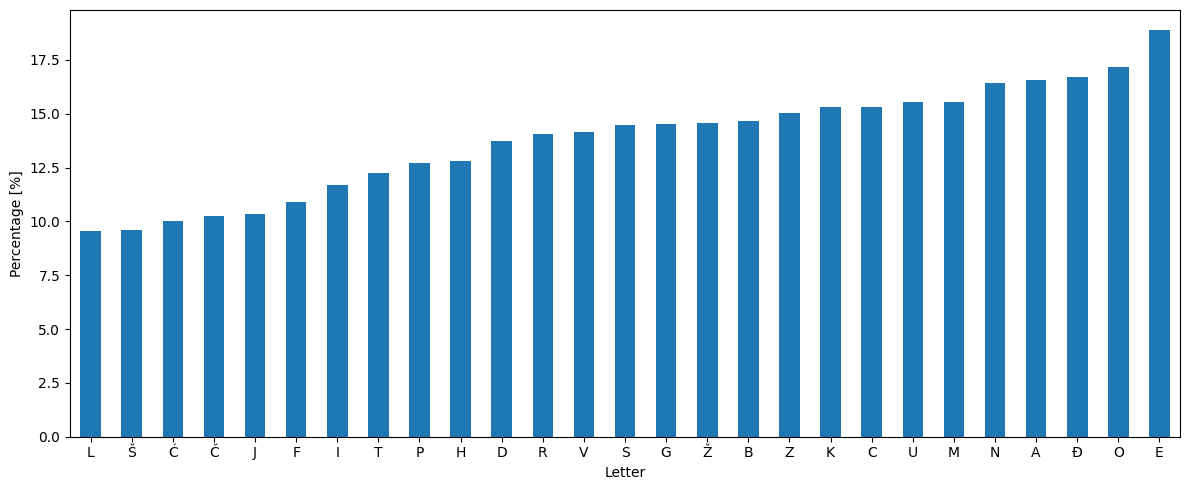

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

def getWhitePixelPercentage(imgPath):
    npPath=np.fromfile(imgPath, dtype=np.uint8)#moramo ovako da napravimo path zbog srpskih karaktera, jer cv2.imread vraca nulu kada vidi naziv fajla sa srpskim karakterom
    img=cv2.imdecode(npPath,cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0
    return np.mean(img>128)


df['Mean White %']=(df['File Destination'].apply(getWhitePixelPercentage)*100).round(3)
#df['Black Pixel Density'].value_counts().plot(kind='bar')
print(df.groupby('Label')['Mean White %'].mean().sort_values())
result=df.groupby('Label')['Mean White %'].mean().sort_values()
result.index=result.index.str.replace('_upper', '')
result.plot(kind='bar', figsize=(12,5))
plt.xticks(rotation=0)
plt.xlabel('Letter')
plt.ylabel('Percentage [%]')
plt.tight_layout()
plt.show()


In [7]:
#slova sa manje od 5% belih piksela na slici
uslov=df[(df['Mean White %'])<5]
path=uslov['File Destination'].sample(1).iloc[0]
decodedPath=np.fromfile(path, dtype=np.uint8)
img=cv2.imdecode(decodedPath,cv2.IMREAD_GRAYSCALE)
img=cv2.resize(img,(100,100))
cv2.imshow("window",img)
cv2.waitKey(0)  
cv2.destroyAllWindows()
len(uslov)

1047

Label
Ć_upper    1.546580
T_upper    1.936357
Č_upper    1.942234
Š_upper    1.944092
P_upper    1.947736
F_upper    2.379957
U_upper    2.415317
Ž_upper    2.491826
H_upper    2.538912
S_upper    2.713335
Z_upper    3.009073
V_upper    3.088269
G_upper    3.133843
K_upper    3.135541
C_upper    3.179488
O_upper    3.297622
R_upper    3.617817
N_upper    3.830577
M_upper    3.888669
Đ_upper    3.942630
B_upper    3.972961
J_upper    4.076359
L_upper    4.112516
E_upper    4.162371
A_upper    4.283900
D_upper    5.451174
I_upper    5.948708
Name: Mean White %, dtype: float64


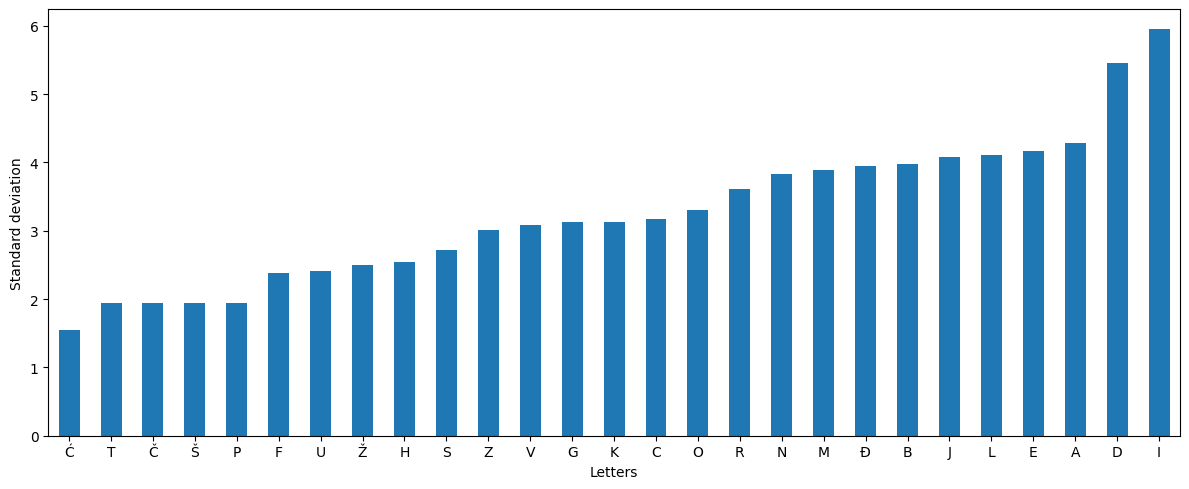

In [8]:
#Standardna devijacija o slovu, sto veca vrednost std-a, to razlicitije pisem to slovo iznova i iznova/veca razlika izmedju malog i velikog slova
print(df.groupby('Label')['Mean White %'].std().sort_values())
stdWhite=df.groupby('Label')['Mean White %'].std().sort_values()
stdWhite.index=stdWhite.index.str.replace('_upper','')
stdWhite.plot(kind='bar', figsize=(12,5))
plt.xticks(rotation=0)
plt.xlabel('Letters')
plt.ylabel('Standard deviation')
plt.tight_layout()
plt.show()

In [9]:
#Pravljenje novog DF-a radi vezbanja
letters=[]
for letter in letterClasses:
    a=letter[0].replace('_upper','')
    letters.append([a])
classDF=pd.DataFrame(letters,columns=['Letters'])
count=df['Label'].value_counts()
count.index=count.index.str.replace('_upper','')
classDF['Count']=classDF['Letters'].map(count)
mean=df.groupby('Label')['Mean White %'].mean().sort_values()
mean.index=mean.index.str.replace('_upper','')
classDF['Mean White %']=classDF['Letters'].map(mean)
std=df.groupby('Label')['Mean White %'].std().sort_values()
std.index=std.index.str.replace('_upper','')
classDF['Std White %']=classDF['Letters'].map(std)
classDF.head()
print(classDF)


   Letters  Count  Mean White %  Std White %
0        A   1754     16.588540     4.283900
1        B   2366     14.654735     3.972961
2        C   1933     15.339501     3.179488
3        D   2467     13.714604     5.451174
4        E   1614     18.878500     4.162371
5        F   2511     10.891916     2.379957
6        G   2419     14.515502     3.133843
7        H   2751     12.824551     2.538912
8        I   1025     11.694874     5.948708
9        J   2679     10.360855     4.076359
10       K   1708     15.297462     3.135541
11       L   1574      9.559760     4.112516
12       M   1928     15.555739     3.888669
13       N   1378     16.422892     3.830577
14       O   2110     17.168474     3.297622
15       P   2141     12.706722     1.947736
16       R   2610     14.059099     3.617817
17       S   2048     14.472126     2.713335
18       T   1464     12.229306     1.936357
19       U   2274     15.530207     2.415317
20       V   2219     14.136203     3.088269
21       Z